In [1]:
import numpy as np
from pathlib import Path
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import umap
from matplotlib import pyplot as plt
from scipy.ndimage import label

/opt/miniconda3/envs/my_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from feature_data_extractor import clean_feature_data, feat_to_idx
from behavior_data_extractor import clean_behavior_data, behavior_to_idx

In [9]:
def umap_data(beh, group, means=False):
    control_path = Path(f'/Users/josieallred/SURF/data/{group}/control')
    mutant_path = Path(f'/Users/josieallred/SURF/data/{group}/mutant')
    
    control_feats, mutant_feats = clean_feature_data(control_path, mutant_path)
    control_behs, mutant_behs = clean_behavior_data(control_path, mutant_path)
    beh_idx = behavior_to_idx(beh, control_path, mutant_path)
    n_c = len(control_feats)
    n_mut = len(mutant_feats)

    control_attack_features = []
    for i in range(n_c):    # iterate through control mice
        attack_mask = (control_behs[i] == beh_idx)    # indices of attack frames

        if np.any(attack_mask):

            if means:
                labeled_bouts, num_bouts = label(attack_mask)

                for bout_id in range(1, num_bouts + 1):
                    bout_indices = (labeled_bouts == bout_id)
                    bout_feats = control_feats[i][:, bout_indices]
                    bout_mean = np.mean(bout_feats, axis=1)
                    control_attack_features.append(bout_mean)
            else:
                attack_features = control_feats[i][:, attack_mask]    # get just features at attack frames
                control_attack_features.extend(attack_features.T)   # add attack frames to aggregated list

    control_attacks = np.array(control_attack_features) # array frames x features(158)

    # do same for mutant
    mut_attack_features = []
    for i in range(n_mut):
        attack_mask = (mutant_behs[i] == beh_idx)

        if np.any(attack_mask):

            if means:
                labeled_bouts, num_bouts = label(attack_mask)
                for bout_id in range(1, num_bouts + 1):
                    bout_indices = (labeled_bouts == bout_id)
                    bout_feats = mutant_feats[i][:, bout_indices]
                    bout_mean = np.mean(bout_feats, axis=1)
                    mut_attack_features.append(bout_mean)

            else:
                attack_features = mutant_feats[i][:, attack_mask]
                mut_attack_features.extend(attack_features.T)

    mutant_attacks = np.array(mut_attack_features)

    return control_attacks, control_attacks.shape[0], mutant_attacks, mutant_attacks.shape[0]

In [4]:
def umap_it(control_attacks, mutant_attacks):
    if control_attacks.size == 0:
        control_attacks = np.empty((0, 158))
    
    if mutant_attacks.size == 0:
        mutant_attacks = np.empty((0, 158))

    data = np.vstack((control_attacks, mutant_attacks))

    scaled_data = StandardScaler().fit_transform(data)

    reducer = umap.UMAP()
    embedding = reducer.fit_transform(scaled_data)

    return embedding

In [22]:
beh = 'attack'
group = 'RIM'
means = True

control_attacks, n_c_attack_frames, mutant_attacks, n_mut_attack_frames = umap_data(beh, group, means)
labels = np.array([0] * n_c_attack_frames + [1] * n_mut_attack_frames)
embedding = umap_it(control_attacks, mutant_attacks)

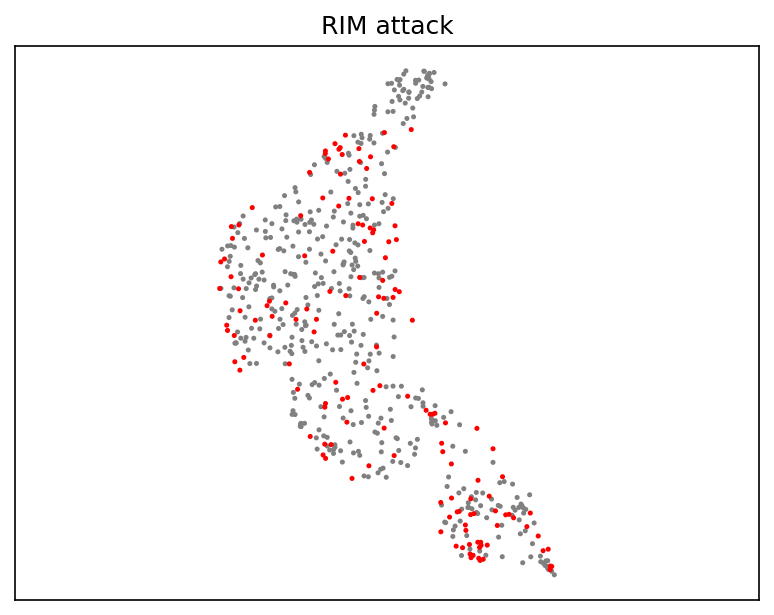

In [23]:
plt.figure(dpi=150)
plt.scatter(embedding[:, 0], embedding[:, 1],
            c = [['gray', 'red'][x] for x in labels],
            s=2) 
plt.title(f'{group} {beh}', fontsize=12)
plt.xticks([])
plt.yticks([])
plt.gca().set_aspect('equal', 'datalim')

if means:
    plt.savefig(f'/Users/josieallred/SURF/code/feature_comparison/umaps/{beh}_{group}_bybout')
else:
    plt.savefig(f'/Users/josieallred/SURF/code/feature_comparison/umaps/{beh}_{group}_byframe')